In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wildfire
from wildfire.utils.functions import G
from wildfire.utils import plots, gradient
from matplotlib.animation import FuncAnimation
from optimizer import optimizer_object
from IPython.display import HTML

import scipy.optimize as opt

%load_ext autoreload
%autoreload 2

In [6]:
## Physical and Simulation Parameters

# Model parameters #
kap = 1
eps = 3e-1
# upc = 3.
alp = 1e-3
q = 1
x_min, x_max = -100, 100
y_min, y_max = -100, 100
t_min, t_max = 0, 12

# Numerical #
# Space
space_method = 'FD'
Nx = 252
Ny = 252
acc = 2
sparse = False

# Time
time_method = 'Euler'
Nt = 225
last = False

# Initial conditions
u0 = lambda x, y: 6 * G(x+25, y+25, 100)

# test case initial fuel 
fuel_properties = {"forest_beta":0.9, "forest_u":3.5, "shrub_beta":0.45, "shrub_u":3.0, "grass_beta":0.2, "grass_u":2.5}
def b_test_intermediate(x, y):
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    xmid = (x[-1,0] - x[0,0]) // 2
    ymid = (y[0,-1] - y[0,0]) //2
    forest_beta, shrub_beta, grass_beta = 0.9, 0.45, 0.2
    B = np.where(x <= xmid, forest_beta, grass_beta).astype(float)
    shrub_mask = (x >= xmid) & (y <= ymid)   
    B[shrub_mask] = shrub_beta

    # homogenous dirichlet boundary conditions
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# initial u_pc (ignition temp) conditions
B_test = b_test_intermediate(*np.meshgrid(np.linspace(x_min, x_max, Nx), np.linspace(y_min, y_max, Ny)))
u_pc = np.ones_like(B_test)
u_pc[B_test==0.9] = 3.5 # forest
u_pc[B_test==0.45] = 3.0 # shrub
u_pc[B_test==0.2] = 2.5 # grass

# asset/weight map, 2 assets on the left-hand side directly in line with fire.
weights = np.ones_like(B_test) * 0.5 # 0.5 weight everywhere in general
asset_weight = 100
x_num, y_num = np.shape(B_test)
asset_size = 12
# first asset
x_asset1, y_asset1 = (2*x_num//4)+35, (2*y_num//4)+30
weights[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = asset_weight
u_pc[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = 3.0
# 2nd asset
x_asset2, y_asset2 = (2*x_num//4), (2*y_num//4)+30
weights[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = asset_weight
u_pc[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = 3.0

def b0_test(x, y):
    B = b_test_intermediate(x, y)
    x_num, y_num = np.shape(B)
    asset_size = 12
    x_asset1, y_asset1 = (2*x_num//4)+35, (2*y_num//4)+30
    x_asset2, y_asset2 = (2*x_num//4), (2*y_num//4)+30
    B[x_asset1-asset_size:x_asset1+asset_size,  y_asset1-asset_size : y_asset1+asset_size] = 0.7 # 0.7 fuel at assets.
    B[x_asset2-asset_size:x_asset2+asset_size,  y_asset2-asset_size : y_asset2+asset_size] = 0.7
    return B


# Wind effect
gamma = 7
w1 = lambda x, y, t: gamma * np.cos(np.pi/4 + x * 0)
w2 = lambda x, y, t: gamma * np.sin(np.pi/4 + x * 0)
V = lambda x, y, t: (w1(x, y, t), w2(x, y, t))
def changing_wind(x, y, t):
    if t<5:
        return (w1(x, y, t), w2(x, y, t))
    else:
        return (gamma * np.sin(0 + x * 0), gamma * np.cos(0 + x * 0))
### PARAMETERS ###

# Physical parameters for the model
physical_parameters = {    
    'kap': kap, # diffusion coefficient
    'eps': eps, # inverse of activation energy
    'upc': u_pc, # u phase change map.
    'q': q, # reaction heat
    'alp': alp, # natural convection,
    # Domain
    'x_lim': (x_min, x_max), # x-axis domain 
    'y_lim': (y_min, y_max), # y-axis domain
    't_lim': (t_min, t_max) # time domain
}

drop_1 = [0, 0, (3/4)*np.pi, 1]
drop_2 = [20, 20, (3/4)*np.pi, 4]
control_vars = np.asarray([drop_1, drop_2])

# CONTROL PARAMETERS
control_params = {
    'v':5,          # velocity of plane
    'sigma_x':5.5,  # size of drop
    'sigma_y':5.5,  # size of drop
    'T':3.0 ,
    'k': 0.6, # original value was 0.5
    'delta': 0.2,
    'control_vars':control_vars
}

In [7]:
def make_logged_functions(opt_obj, J_ref, evaluation_history, gradient_history):
    def logged_fun(z):
        z = np.asarray(z, dtype=float).copy()

        J_raw = float(opt_obj.objective_function(z))
        J_scaled = J_raw / J_ref

        evaluation_history.append({
            "x": z,
            "fun": J_scaled,
            "fun_raw": J_raw,
            "control_vars": opt_obj.denormalize(z).copy(),
            "optimality": np.nan,
            "evaluation": len(evaluation_history),
        })

        return J_scaled

    def logged_jac(z):
        z = np.asarray(z, dtype=float).copy()
        grad_scaled = np.asarray(opt_obj.gradient(z), dtype=float) / J_ref

        gradient_history.append({
            "x": z,
            "control_vars": opt_obj.denormalize(z).copy(),
            "gradient": grad_scaled.copy(),
            "gradient_norm": np.linalg.norm(grad_scaled),
            "gradient_evaluation": len(gradient_history),
        })

        return grad_scaled

    return logged_fun, logged_jac


def make_lbfgsb_callback(iteration_history, evaluation_history):
    def callback(xk):
        xk = np.asarray(xk, dtype=float).copy()

        # L-BFGS-B should have evaluated this accepted point already.
        matching_evaluation = next(
            (
                entry for entry in reversed(evaluation_history)
                if np.array_equal(entry["x"], xk)
            ),
            None,
        )

        iteration_history.append({
            "x": xk,
            "control_vars": (
                matching_evaluation["control_vars"].copy()
                if matching_evaluation is not None else None
            ),
            "fun": (
                matching_evaluation["fun"]
                if matching_evaluation is not None else np.nan
            ),
            "fun_raw": (
                matching_evaluation["fun_raw"]
                if matching_evaluation is not None else np.nan
            ),
            "optimality": np.nan,  # L-BFGS-B does not provide this in callback
            "iteration": len(iteration_history),
        })

    return callback

def plot_variable(
    history,
    i,
    plot_after=0,
    physical=False,
    raw_objective=False,
    x_axis_label="Iteration",
):
    if not 0 <= i <= 7:
        raise ValueError("i must be between 0 and 7")

    indices = np.arange(len(history))

    if physical:
        x_values = np.array([
            entry["control_vars"][i] for entry in history
        ])
        variable_label = f"physical control[{i}]"
    else:
        x_values = np.array([
            entry["x"][i] for entry in history
        ])
        variable_label = f"normalized z[{i}]"

    fun_key = "fun_raw" if raw_objective else "fun"
    fun_values = np.array([
        entry.get(fun_key, np.nan) for entry in history
    ])

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(
        indices[plot_after:],
        x_values[plot_after:],
        "bo-",
        ms=3,
        label=variable_label,
    )
    ax1.set_xlabel(x_axis_label)
    ax1.set_ylabel(variable_label)
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        indices[plot_after:],
        fun_values[plot_after:],
        "rs--",
        ms=3,
        label="Objective",
    )
    ax2.set_ylabel(
        "Unscaled objective" if raw_objective else "Scaled objective"
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.tight_layout()
    plt.show()

In [8]:
### Optimizing Spray Parameters --> try with changing wind, all params same as before.
evaluation_history = []
gradient_history = []
iteration_history = []

normalization_ranges = np.array([[x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10], [x_min, x_max], [y_min, y_max], [0, 2*np.pi], [0, 10]])

opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)

x0 = np.asarray([-25, -25, (1/4)*np.pi, 0, 0, 0, (3/4)*np.pi, 3]) # initial guess
z0 = (x0 - normalization_ranges[:,0])/ (normalization_ranges[:,1] - normalization_ranges[:,0]) 
J_ref = opt_obj.objective_function(z0)

func_scaled, jac_scaled = make_logged_functions(
    opt_obj,
    J_ref,
    evaluation_history,
    gradient_history,
)
callback = make_lbfgsb_callback(
    iteration_history,
    evaluation_history,
)

lb, ub = np.zeros(8), np.ones(8) # generic bounds for normalized variables
T = control_params["T"]
A = np.zeros((1, 8))
A[0, 3] = -1    # x4
A[0, 7] =  1 
time_constraint = opt.LinearConstraint(A, T/10, np.inf) # second drop must be atleast after the first drop finishes.
bounds_z = opt.Bounds(lb=np.zeros(8), ub=np.ones(8))

res = opt.minimize(func_scaled, x0=z0, args=(), method="SLSQP", jac=jac_scaled, bounds=bounds_z, constraints=time_constraint,
                     options={"maxiter": 150,"disp":True,"ftol":1e-6}, callback=callback)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6421992983001319
            Iterations: 51
            Function evaluations: 486
            Gradient evaluations: 47


In [19]:
def plot_function_evaluations(history, i, plot_after=0, physical=True):
    if not 0 <= i <= 7:
        raise ValueError("i must be between 0 and 7")

    eval_num = np.arange(len(history))

    if physical:
        x_values = np.array([
            entry["control_vars"][i] for entry in history
        ])
        x_label = f"physical control[{i}]"
    else:
        x_values = np.array([
            entry["x"][i] for entry in history
        ])
        x_label = f"normalized z[{i}]"

    fun_values = np.array([
        entry["fun_raw"] for entry in history
    ])

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(
        eval_num[plot_after:],
        x_values[plot_after:],
        "bo-",
        ms=3,
        label=x_label,
    )
    ax1.set_xlabel("Objective-function evaluation")
    ax1.set_ylabel(x_label)
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        eval_num[plot_after:],
        fun_values[plot_after:],
        "rs--",
        ms=3,
        label="Objective",
    )
    ax2.set_ylabel("Unscaled objective")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(f"Every function evaluation: control[{i}] and objective")
    plt.tight_layout()
    plt.show()

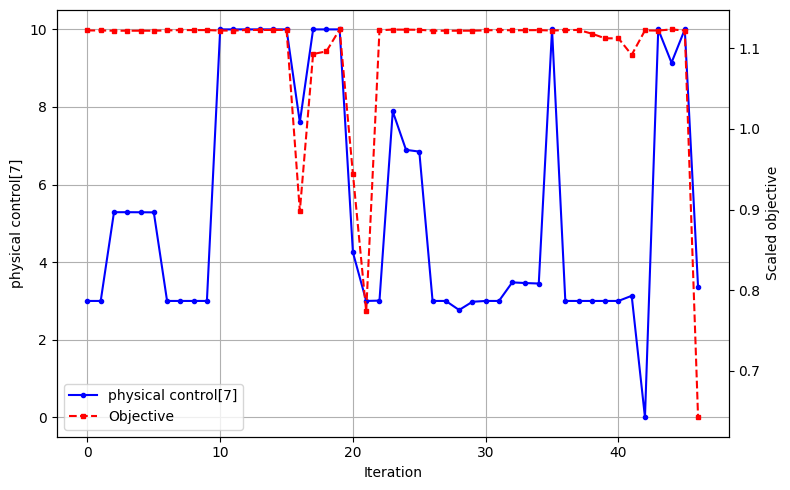

In [41]:
# use iteration_history to see optimizer accepted points, use evaluation_history to see all evaluated function values
# i= 0 through 7 (0-3 is drop 1, 4-7 is drop 2, in the order of x_position, y_position, angle_of_drop, time_of_drop)
# keep physical=True to see actual variable values, else will see normalized variable values.

plot_variable(iteration_history, i=7, plot_after=0, physical=True)

In [9]:
#z0 = opt_obj.control_params["control_vars"].ravel()
print(res)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.6421992983001319
       x: [ 4.124e-01  3.989e-01  4.654e-02  8.489e-04  4.888e-01
            4.915e-01  1.015e-01  3.357e-01]
     nit: 51
     jac: [-6.879e+03  9.143e+04  8.459e+03  1.837e+02  5.516e+01
           -2.427e+02  1.264e+01 -3.586e+02]
    nfev: 486
    njev: 47


x0 is [-1.75295664e+01 -2.02286256e+01  2.92445898e-01  8.48897229e-03
 -2.23646913e+00 -1.70327001e+00  6.37728655e-01  3.35746499e+00]
Objective function value is 32403.295285386557
t:  0.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


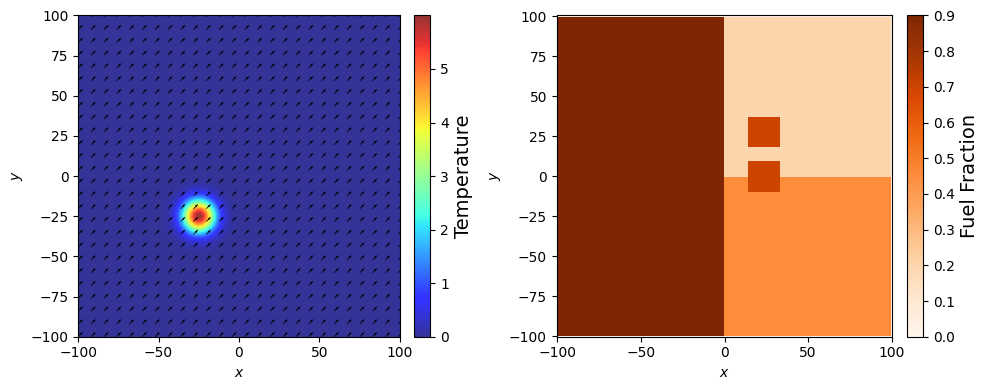

t:  2.986666666666667
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


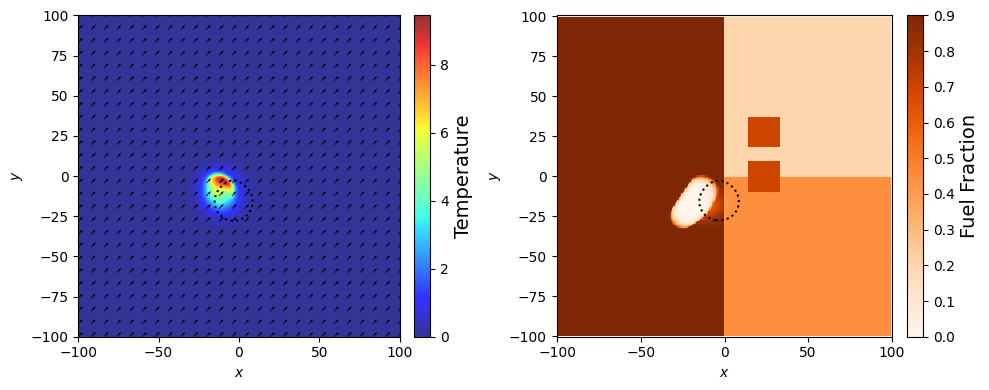

t:  5.973333333333334
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


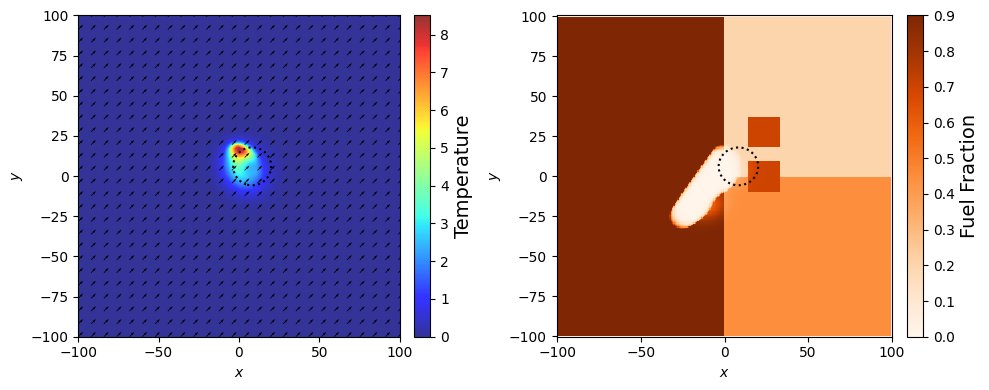

t:  8.96
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


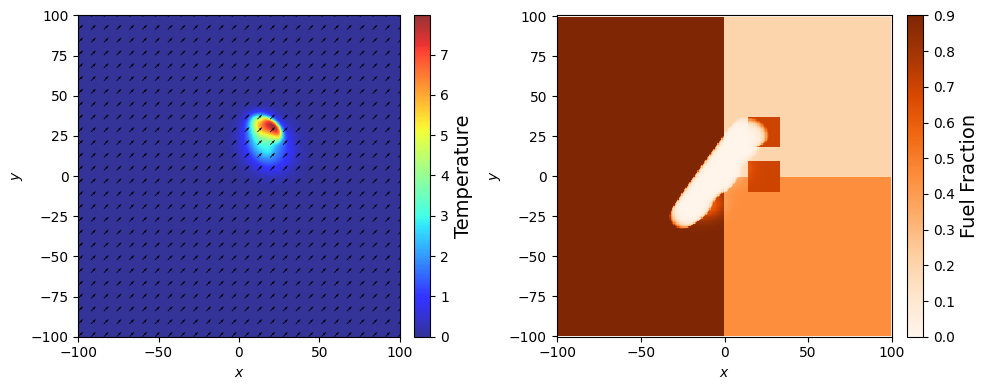

t:  12.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


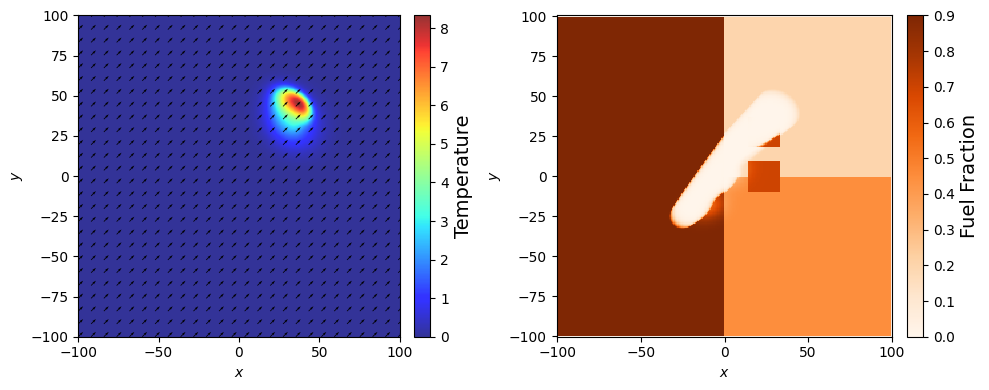

In [39]:
z0 = res.x
opt_obj1 = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)
x0 = opt_obj1.denormalize(z0)
#x0 = np.asarray([-25, -25, (1/4)*np.pi, 0, 0, 0, (3/4)*np.pi, 3]) # initial guess
control_params['control_vars'] = x0

# test with changing wind
opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b0_test, V, weights, normalization_ranges)

print(f"x0 is {x0}")
t, X, Y, U, B = opt_obj.forward_eval(x0 , full_out=True)
print(f"Objective function value is {opt_obj.objective_function(z0)}")
Ns = np.linspace(0, Nt, 5, dtype=int)
for n in Ns:
    plots.UBs(n, t, X, Y, U, B, V, control_params, forward=True)